# 🔍 Fingerprint Authenticity Detection
Detects **Real vs Fake** fingerprints and classifies altered ones as **Easy / Medium / Hard**.

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from PIL import Image

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "figure.facecolor": "#0d0d1a", "axes.facecolor": "#12122a",
    "text.color": "white", "axes.labelcolor": "white",
    "xtick.color": "white", "ytick.color": "white",
})

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Libraries loaded — Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")


✅ Libraries loaded — Device: cpu


## ⚙️ Dataset Path & Config

In [2]:
# ── Auto-detect dataset path ──────────────────────────────────────────────────
def find_dataset_path():
    candidates = [
        "/kaggle/input/datasets/ruizgara/socofing/SOCOFing",
        "/kaggle/input/socofing",
        "/kaggle/input/sokoto-coventry-fingerprint-dataset-socofing/SOCOFing",
        "/kaggle/input/sokoto-coventry-fingerprint-dataset-socofing",
    ]
    for c in candidates:
        p = Path(c)
        if p.exists():
            if (p / "Real").exists() or (p / "Altered").exists():
                return p
            for sub in p.iterdir():
                if sub.is_dir() and ((sub/"Real").exists() or (sub/"Altered").exists()):
                    return sub
    return None

def resolve_class_dirs(base_path):
    """Find Real & Altered dirs regardless of exact folder naming."""
    known_real    = ["Real", "real", "genuine", "Genuine", "authentic"]
    known_altered = ["Altered", "altered", "Fake", "fake", "forged", "Forged"]

    real_dir = next((base_path / n for n in known_real    if (base_path / n).exists()), None)
    alt_dir  = next((base_path / n for n in known_altered if (base_path / n).exists()), None)

    if real_dir is None or alt_dir is None:          # fallback: largest = Real
        subdirs = sorted([d for d in base_path.iterdir() if d.is_dir()],
                         key=lambda d: sum(1 for _ in d.rglob("*")), reverse=True)
        if len(subdirs) >= 2:
            real_dir, alt_dir = subdirs[0], subdirs[1]
            print(f"⚠️  Auto-detected: Real←{real_dir.name}  Altered←{alt_dir.name}")
        else:
            raise RuntimeError(f"Cannot find class dirs under {base_path}")
    return real_dir, alt_dir

DATASET_PATH = find_dataset_path()
assert DATASET_PATH is not None, "❌ Dataset not found — check /kaggle/input"
REAL_DIR, ALT_DIR = resolve_class_dirs(DATASET_PATH)

# ── Config ────────────────────────────────────────────────────────────────────
CONFIG = {
    "img_size"      : 128,
    "batch_size"    : 32,
    "epochs"        : 30,
    "lr"            : 1e-3,
    "weight_decay"  : 1e-4,
    "max_per_class" : 2000,   # raise for more accuracy, lower for faster run
    "val_split"     : 0.15,
    "test_split"    : 0.15,
    "patience"      : 6,
    "random_state"  : 42,
    "use_pretrained": True,
}
torch.manual_seed(CONFIG["random_state"])
np.random.seed(CONFIG["random_state"])

exts = [".bmp", ".BMP", ".png", ".jpg", ".jpeg"]
real_count = len([p for p in REAL_DIR.iterdir() if p.suffix in exts])
alt_subdirs = [d for d in ALT_DIR.iterdir() if d.is_dir()]
alt_count   = (sum(len([p for p in s.iterdir() if p.suffix in exts]) for s in alt_subdirs)
               or len([p for p in ALT_DIR.iterdir() if p.suffix in exts]))

print(f"✅ Dataset : {DATASET_PATH.name}")
print(f"   Real    : {real_count:,} images  |  Altered: {alt_count:,} images")
print(f"   Altered sub-folders: {[d.name for d in alt_subdirs] or ['flat']}")


✅ Dataset : SOCOFing
   Real    : 6,000 images  |  Altered: 49,270 images
   Altered sub-folders: ['Altered-Medium', 'Altered-Easy', 'Altered-Hard']


## 📊 Dataset Distribution

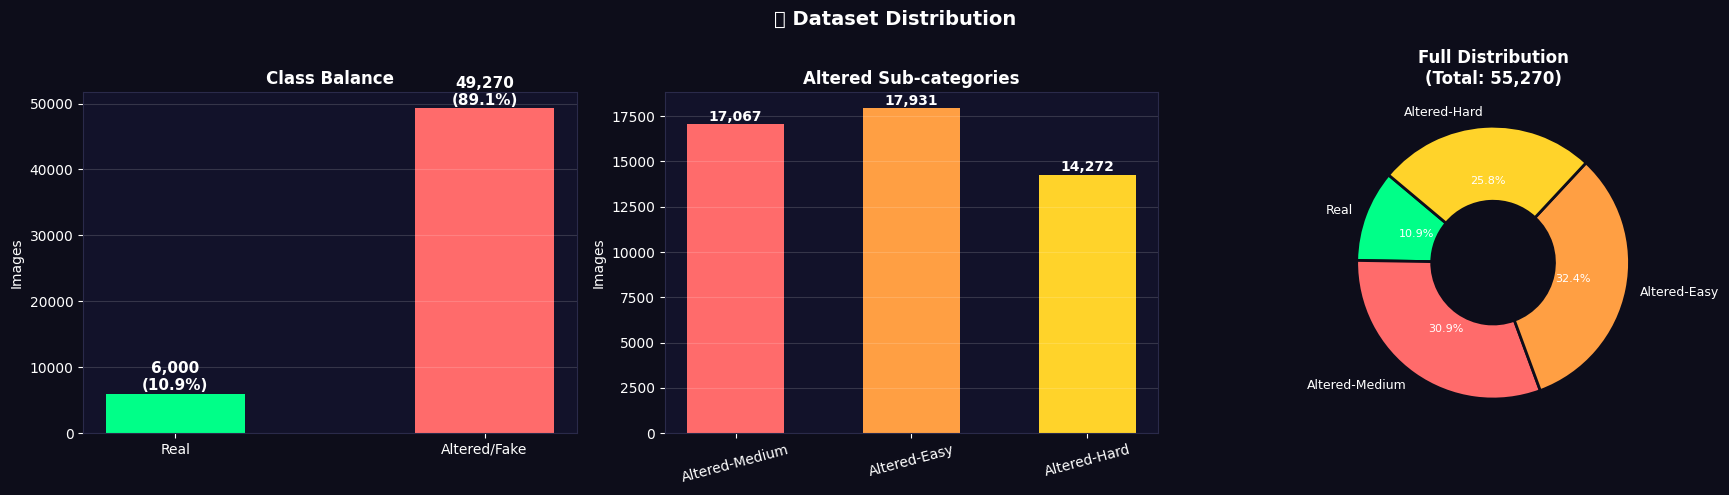

✅ Real: 6,000  |  Fake: 49,270  |  Total: 55,270


In [3]:
exts = [".bmp", ".BMP", ".png", ".jpg", ".jpeg"]
real_imgs_all = [p for p in REAL_DIR.iterdir() if p.suffix in exts]

alt_subfolders = {}
for sub in ALT_DIR.iterdir():
    if sub.is_dir():
        imgs = [p for p in sub.iterdir() if p.suffix in exts]
        if imgs: alt_subfolders[sub.name] = len(imgs)
if not alt_subfolders:
    alt_subfolders["Altered"] = len([p for p in ALT_DIR.iterdir() if p.suffix in exts])

total_real = len(real_imgs_all)
total_fake = sum(alt_subfolders.values())
total_all  = total_real + total_fake

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = ["#ff6b6b", "#ff9f43", "#ffd32a", "#e84393", "#a29bfe"]

# Plot 1 — Class Balance
ax = axes[0]
ax.set_facecolor("#12122a")
bars = ax.bar(["Real", "Altered/Fake"], [total_real, total_fake],
              color=["#00ff88", "#ff6b6b"], width=0.45, edgecolor="none")
ax.set_title("Class Balance", color="white", fontsize=12, fontweight="bold")
ax.set_ylabel("Images", color="white")
for bar, v in zip(bars, [total_real, total_fake]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{v:,}\n({v/total_all*100:.1f}%)", ha="center", va="bottom",
            color="white", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.15, color="white", axis="y")
for s in ax.spines.values(): s.set_edgecolor("#2a2a4a")

# Plot 2 — Altered Sub-categories
ax = axes[1]
ax.set_facecolor("#12122a")
names, counts = list(alt_subfolders.keys()), list(alt_subfolders.values())
bars = ax.bar(names, counts, color=palette[:len(names)], width=0.55, edgecolor="none")
ax.set_title("Altered Sub-categories", color="white", fontsize=12, fontweight="bold")
ax.set_ylabel("Images", color="white")
ax.tick_params(axis="x", rotation=15)
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{v:,}", ha="center", va="bottom", color="white", fontsize=10, fontweight="bold")
ax.grid(True, alpha=0.15, color="white", axis="y")
for s in ax.spines.values(): s.set_edgecolor("#2a2a4a")

# Plot 3 — Donut
ax = axes[2]
ax.set_facecolor("#12122a")
wedge_sizes  = [total_real] + counts
wedge_labels = ["Real"] + names
wedge_colors = ["#00ff88"] + palette[:len(names)]
_, _, autotexts = ax.pie(wedge_sizes, labels=wedge_labels, colors=wedge_colors,
    autopct="%1.1f%%", startangle=140,
    wedgeprops=dict(width=0.55, edgecolor="#0d0d1a", linewidth=2),
    textprops=dict(color="white", fontsize=9))
for at in autotexts: at.set_fontsize(8)
ax.set_title(f"Full Distribution\n(Total: {total_all:,})", color="white", fontsize=12, fontweight="bold")

plt.suptitle("📊 Dataset Distribution", color="white", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/dataset_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1a")
plt.show()
print(f"✅ Real: {total_real:,}  |  Fake: {total_fake:,}  |  Total: {total_all:,}")


## 🔍 Sample Images (Before Training)

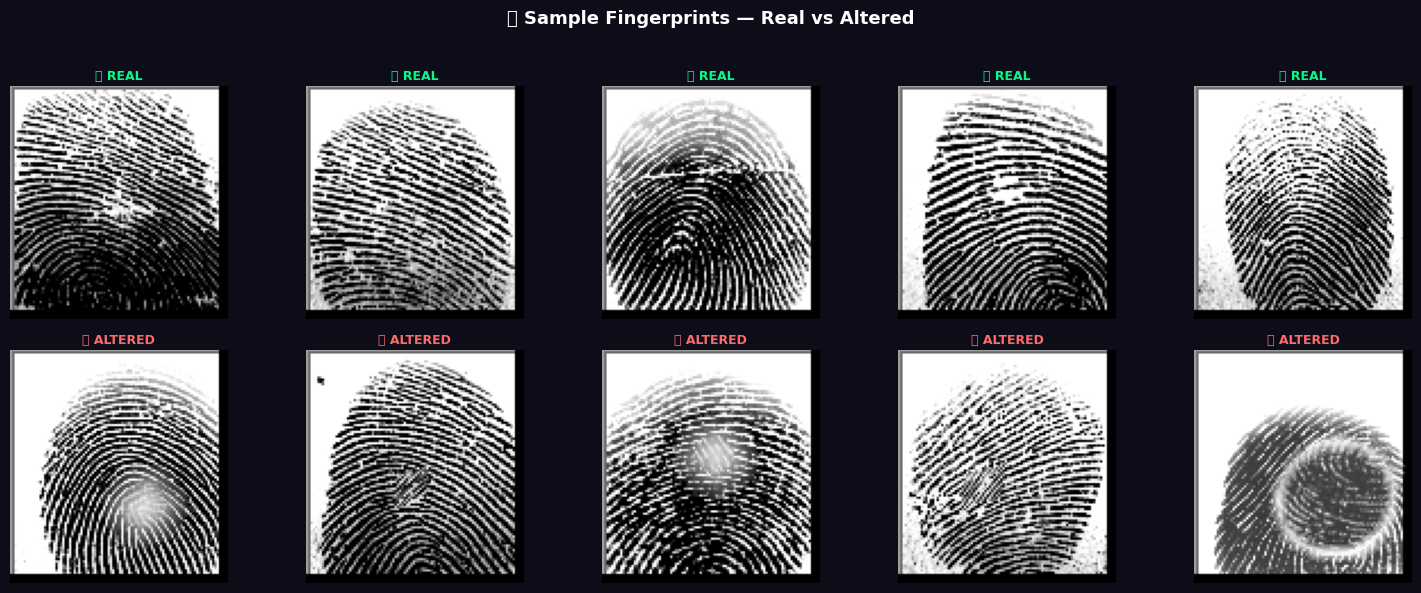

✅ Saved → sample_images.png


In [4]:
def show_sample_images(real_dir, alt_dir, n_each=5):
    exts = [".bmp", ".BMP", ".png", ".jpg", ".jpeg"]
    real_samples = np.random.choice(
        [p for p in real_dir.iterdir() if p.suffix in exts], n_each, replace=False)

    alt_all = []
    for sub in alt_dir.iterdir():
        if sub.is_dir(): alt_all += [p for p in sub.iterdir() if p.suffix in exts]
    if not alt_all: alt_all = [p for p in alt_dir.iterdir() if p.suffix in exts]
    fake_samples = np.random.choice(alt_all, n_each, replace=False)

    fig, axes = plt.subplots(2, n_each, figsize=(n_each * 3, 6))
    fig.patch.set_facecolor("#0d0d1a")
    for col, (rp, fp) in enumerate(zip(real_samples, fake_samples)):
        for row, (path, label, color) in enumerate([
            (rp, "✅ REAL",    "#00ff88"),
            (fp, "❌ ALTERED", "#ff6b6b"),
        ]):
            ax = axes[row][col]
            ax.set_facecolor("#12122a")
            ax.imshow(Image.open(path).convert("L"), cmap="gray")
            ax.set_title(label, color=color, fontsize=9, fontweight="bold", pad=4)
            ax.axis("off")
            for s in ax.spines.values(): s.set_edgecolor(color); s.set_linewidth(2)
    plt.suptitle("🔍 Sample Fingerprints — Real vs Altered",
                 color="white", fontsize=13, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("/kaggle/working/sample_images.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1a")
    plt.show()
    print("✅ Saved → sample_images.png")

show_sample_images(REAL_DIR, ALT_DIR)


## 📦 Data Loading

Two label sets are built:
- **Binary label** → `1 = Real`, `0 = Fake`
- **Difficulty label** → `0 = Real`, `1 = Easy`, `2 = Medium`, `3 = Hard`

In [5]:
TRAIN_TRANSFORMS = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])
EVAL_TRANSFORMS = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

# Difficulty map: sub-folder name → label (0=Real handled separately)
DIFFICULTY_MAP = {
    "Easy": 1, "Altered-Easy": 1,
    "Medium": 2, "Altered-Medium": 2,
    "Hard": 3, "Altered-Hard": 3,
}
DIFFICULTY_NAMES = {0: "Real", 1: "Easy", 2: "Medium", 3: "Hard"}

class FingerprintDataset(Dataset):
    def __init__(self, file_paths, binary_labels, diff_labels, transform=None):
        self.paths         = file_paths
        self.binary_labels = binary_labels   # 1=Real, 0=Fake
        self.diff_labels   = diff_labels     # 0=Real,1=Easy,2=Med,3=Hard
        self.transform     = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("L")
        if self.transform: img = self.transform(img)
        return img, self.binary_labels[idx], self.diff_labels[idx]

def collect_paths(real_dir, alt_dir, max_per_class=2000):
    exts = [".bmp", ".BMP", ".png", ".jpg", ".jpeg"]
    real_imgs = [p for p in real_dir.iterdir() if p.suffix in exts][:max_per_class]

    fake_imgs, fake_diff = [], []
    subdirs = [d for d in alt_dir.iterdir() if d.is_dir()]
    if subdirs:
        for sub in subdirs:
            diff_lbl = DIFFICULTY_MAP.get(sub.name, 1)   # unknown → Easy
            imgs = [p for p in sub.iterdir() if p.suffix in exts]
            fake_imgs.extend(imgs)
            fake_diff.extend([diff_lbl] * len(imgs))
    else:
        imgs = [p for p in alt_dir.iterdir() if p.suffix in exts]
        fake_imgs.extend(imgs)
        fake_diff.extend([1] * len(imgs))       # flat folder → Easy

    # Balance per difficulty bucket
    from collections import defaultdict
    buckets = defaultdict(list)
    for p, d in zip(fake_imgs, fake_diff):
        buckets[d].append(p)
    cap = max_per_class // max(len(buckets), 1)
    fake_imgs, fake_diff = [], []
    for d, ps in buckets.items():
        chosen = ps[:cap]
        fake_imgs.extend(chosen)
        fake_diff.extend([d] * len(chosen))

    n = min(len(real_imgs), len(fake_imgs))
    real_imgs = real_imgs[:n];  fake_imgs = fake_imgs[:n];  fake_diff = fake_diff[:n]

    paths        = real_imgs + fake_imgs
    binary_lbls  = [1]*len(real_imgs) + [0]*len(fake_imgs)
    diff_lbls    = [0]*len(real_imgs) + fake_diff      # Real = 0

    print(f"  Real: {len(real_imgs):,}  |  Fake: {len(fake_imgs):,}  |  Total: {len(paths):,}")
    for d, name in DIFFICULTY_NAMES.items():
        cnt = diff_lbls.count(d)
        if cnt: print(f"    {name}: {cnt:,}")
    return paths, binary_lbls, diff_lbls

print("Collecting paths ...")
all_paths, all_binary, all_diff = collect_paths(REAL_DIR, ALT_DIR, CONFIG["max_per_class"])

# ── Split ─────────────────────────────────────────────────────────────────────
p_tr, p_tmp, b_tr, b_tmp, d_tr, d_tmp = train_test_split(
    all_paths, all_binary, all_diff,
    test_size=CONFIG["val_split"] + CONFIG["test_split"],
    stratify=all_binary, random_state=CONFIG["random_state"])

val_ratio = CONFIG["val_split"] / (CONFIG["val_split"] + CONFIG["test_split"])
p_val, p_test, b_val, b_test, d_val, d_test = train_test_split(
    p_tmp, b_tmp, d_tmp,
    test_size=1-val_ratio, stratify=b_tmp, random_state=CONFIG["random_state"])

train_ds = FingerprintDataset(p_tr,   b_tr,   d_tr,   TRAIN_TRANSFORMS)
val_ds   = FingerprintDataset(p_val,  b_val,  d_val,  EVAL_TRANSFORMS)
test_ds  = FingerprintDataset(p_test, b_test, d_test, EVAL_TRANSFORMS)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2, pin_memory=True)

# Fast lookup for inference smoke-test
path_to_labels = {str(p): (b, d) for p, b, d in zip(p_test, b_test, d_test)}

print(f"\n✅ DataLoaders ready — Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")


  Real: 1,998  |  Fake: 1,998  |  Total: 3,996
    Real: 1,998
    Easy: 666
    Medium: 666
    Hard: 666

✅ DataLoaders ready — Train: 2,797  Val: 599  Test: 600


## 🧠 Model — MobileNetV2 (Dual-Head)

One shared backbone, two heads:
- **Binary head** → Real / Fake
- **Difficulty head** → Real / Easy / Medium / Hard

In [6]:
class DualHeadFingerprint(nn.Module):
    """
    MobileNetV2 backbone with two classification heads:
      - binary_head  : 1 output (sigmoid) → Real vs Fake
      - diff_head    : 4 outputs (softmax) → Real / Easy / Medium / Hard
    """
    def __init__(self, use_pretrained=True):
        super().__init__()
        backbone = models.mobilenet_v2(pretrained=use_pretrained)
        # Freeze first 14 blocks (keep low-level edge detectors)
        for i, layer in enumerate(backbone.features):
            if i < 14:
                for p in layer.parameters(): p.requires_grad = False
        self.features  = backbone.features
        self.pool      = nn.AdaptiveAvgPool2d(1)
        in_f           = backbone.classifier[1].in_features

        self.shared = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(in_f, 256), nn.ReLU(), nn.Dropout(0.3))
        self.binary_head = nn.Linear(256, 1)   # Real vs Fake
        self.diff_head   = nn.Linear(256, 4)   # Real/Easy/Medium/Hard

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        x = self.shared(x)
        return self.binary_head(x), self.diff_head(x)

model = DualHeadFingerprint(CONFIG["use_pretrained"]).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model ready — Total: {total:,}  Trainable: {trainable:,} ({trainable/total*100:.1f}%)")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 134MB/s]

✅ Model ready — Total: 2,553,093  Trainable: 2,010,565 (78.8%)


## 🔧 Training Functions

In [7]:
BCE = nn.BCEWithLogitsLoss()
CE  = nn.CrossEntropyLoss()

def compute_loss(bin_logit, diff_logit, bin_lbl, diff_lbl):
    """Combined loss: 0.6 * binary + 0.4 * difficulty."""
    l_bin  = BCE(bin_logit, bin_lbl.float().unsqueeze(1))
    l_diff = CE(diff_logit, diff_lbl.long())
    return 0.6 * l_bin + 0.4 * l_diff

def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, b_lbl, d_lbl in loader:
        imgs, b_lbl, d_lbl = imgs.to(device), b_lbl.to(device), d_lbl.to(device)
        optimizer.zero_grad()
        bin_logit, diff_logit = model(imgs)
        loss = compute_loss(bin_logit, diff_logit, b_lbl, d_lbl)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        preds    = (torch.sigmoid(bin_logit) >= 0.5).float().squeeze(1)
        correct += (preds == b_lbl.float()).sum().item()
        total   += b_lbl.size(0)
        total_loss += loss.item() * b_lbl.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_bin = [], []
    for imgs, b_lbl, d_lbl in loader:
        imgs, b_lbl, d_lbl = imgs.to(device), b_lbl.to(device), d_lbl.to(device)
        bin_logit, diff_logit = model(imgs)
        loss  = compute_loss(bin_logit, diff_logit, b_lbl, d_lbl)
        probs = torch.sigmoid(bin_logit).squeeze(1)
        preds = (probs >= 0.5).float()
        correct    += (preds == b_lbl.float()).sum().item()
        total      += b_lbl.size(0)
        total_loss += loss.item() * b_lbl.size(0)
        all_probs.extend(probs.cpu().numpy())
        all_bin.extend(b_lbl.cpu().numpy())
    auc = roc_auc_score(all_bin, all_probs)
    return total_loss / total, correct / total, auc

print("✅ Training functions ready")


✅ Training functions ready


## 🚀 Training

In [8]:
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"], eta_min=1e-6)

history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "val_auc":[]}
best_val_acc, patience_ctr, best_weights = 0.0, 0, None

print(f"Training for up to {CONFIG['epochs']} epochs (patience={CONFIG['patience']}) ...")
print("-" * 70)

for epoch in range(1, CONFIG["epochs"] + 1):
    tr_loss, tr_acc            = train_epoch(model, train_loader, optimizer, DEVICE)
    vl_loss, vl_acc, vl_auc   = eval_epoch(model, val_loader, DEVICE)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(vl_acc)
    history["val_auc"].append(vl_auc)

    marker = ""
    if vl_acc > best_val_acc:
        best_val_acc  = vl_acc
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
        marker        = " ✅ best"
    else:
        patience_ctr += 1
        if patience_ctr >= CONFIG["patience"]:
            print(f"  Early stopping at epoch {epoch}.")
            break

    print(f"Epoch {epoch:02d}/{CONFIG['epochs']}  "
          f"TrainAcc: {tr_acc*100:.2f}%  ValAcc: {vl_acc*100:.2f}%  "
          f"AUC: {vl_auc:.4f}  LR: {scheduler.get_last_lr()[0]:.2e}{marker}")

model.load_state_dict(best_weights)
print("-" * 70)
print(f"✅ Training complete — Best Val Acc: {best_val_acc*100:.2f}%")


Training for up to 30 epochs (patience=6) ...
----------------------------------------------------------------------
Epoch 01/30  TrainAcc: 85.27%  ValAcc: 91.99%  AUC: 0.9710  LR: 9.97e-04 ✅ best
Epoch 02/30  TrainAcc: 91.38%  ValAcc: 92.49%  AUC: 0.9670  LR: 9.89e-04 ✅ best
Epoch 03/30  TrainAcc: 93.06%  ValAcc: 93.16%  AUC: 0.9783  LR: 9.76e-04 ✅ best
Epoch 04/30  TrainAcc: 93.24%  ValAcc: 94.32%  AUC: 0.9776  LR: 9.57e-04 ✅ best
Epoch 05/30  TrainAcc: 94.28%  ValAcc: 93.82%  AUC: 0.9799  LR: 9.33e-04
Epoch 06/30  TrainAcc: 94.14%  ValAcc: 94.16%  AUC: 0.9811  LR: 9.05e-04
Epoch 07/30  TrainAcc: 94.85%  ValAcc: 92.99%  AUC: 0.9732  LR: 8.72e-04
Epoch 08/30  TrainAcc: 94.28%  ValAcc: 94.32%  AUC: 0.9766  LR: 8.35e-04
Epoch 09/30  TrainAcc: 94.28%  ValAcc: 94.49%  AUC: 0.9788  LR: 7.94e-04 ✅ best
Epoch 10/30  TrainAcc: 94.32%  ValAcc: 95.33%  AUC: 0.9885  LR: 7.50e-04 ✅ best
Epoch 11/30  TrainAcc: 95.14%  ValAcc: 94.16%  AUC: 0.9880  LR: 7.04e-04
Epoch 12/30  TrainAcc: 95.78%  ValAcc:

## 📈 Training History

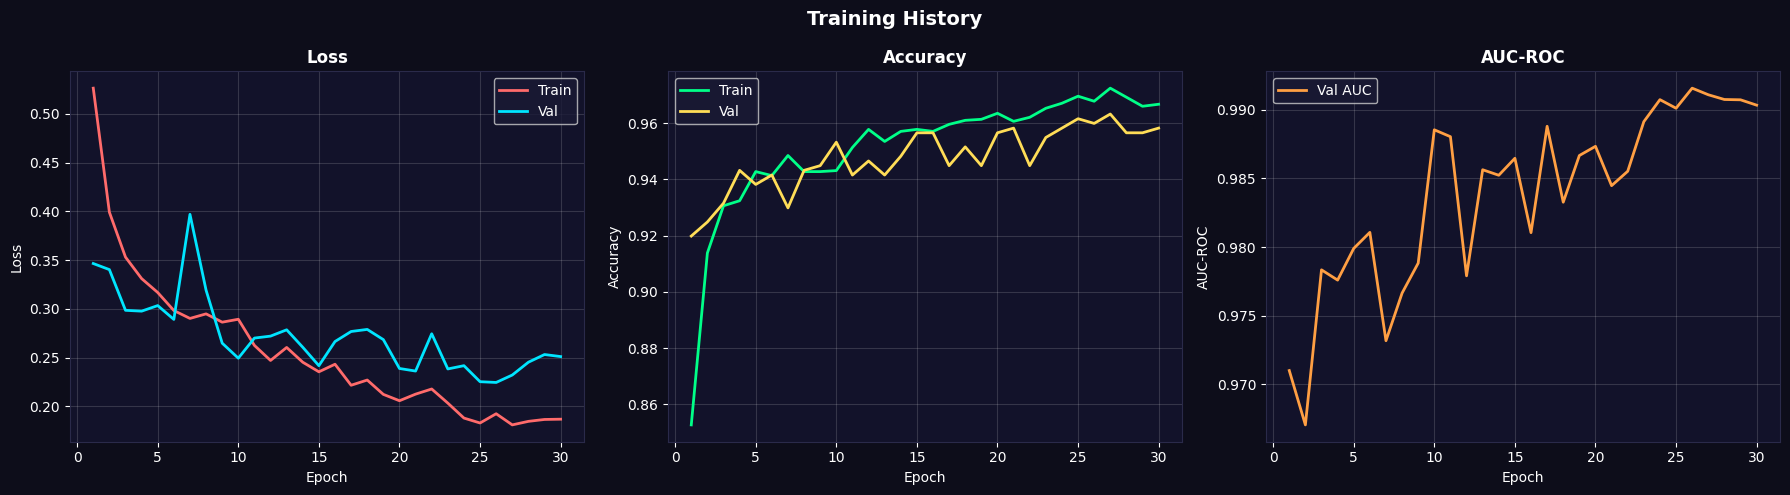

✅ Saved → training_history.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_ran = range(1, len(history["train_acc"]) + 1)

for ax, tr, vl, ylabel, tr_lbl, vl_lbl, c1, c2 in [
    (axes[0], history["train_loss"], history["val_loss"], "Loss",     "Train", "Val", "#ff6b6b", "#00e5ff"),
    (axes[1], history["train_acc"],  history["val_acc"],  "Accuracy", "Train", "Val", "#00ff88", "#ffdd57"),
    (axes[2], [None]*len(history["val_auc"]), history["val_auc"], "AUC-ROC", None, "Val AUC", None, "#ff9f43"),
]:
    ax.set_facecolor("#12122a")
    if tr[0] is not None: ax.plot(epochs_ran, tr, color=c1, linewidth=2, label=tr_lbl)
    ax.plot(epochs_ran, vl, color=c2, linewidth=2, label=vl_lbl)
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontsize=12, fontweight="bold")
    ax.legend(facecolor="#1a1a35", labelcolor="white")
    ax.grid(True, alpha=0.15, color="white")
    for s in ax.spines.values(): s.set_edgecolor("#2a2a4a")

plt.suptitle("Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/training_history.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1a")
plt.show()
print("✅ Saved → training_history.png")


## 🧪 Test Evaluation

  BINARY (Real / Fake)
  Accuracy : 97.83%   AUC-ROC: 0.9954

              precision    recall  f1-score   support

        Fake       0.99      0.97      0.98       300
        Real       0.97      0.99      0.98       300

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600

  DIFFICULTY (Real / Easy / Medium / Hard)
  Accuracy : 83.67%

              precision    recall  f1-score   support

        Real       0.96      0.99      0.98       300
        Easy       0.85      0.78      0.81        91
      Medium       0.57      0.63      0.60        98
        Hard       0.72      0.65      0.68       111

    accuracy                           0.84       600
   macro avg       0.78      0.76      0.77       600
weighted avg       0.84      0.84      0.84       600



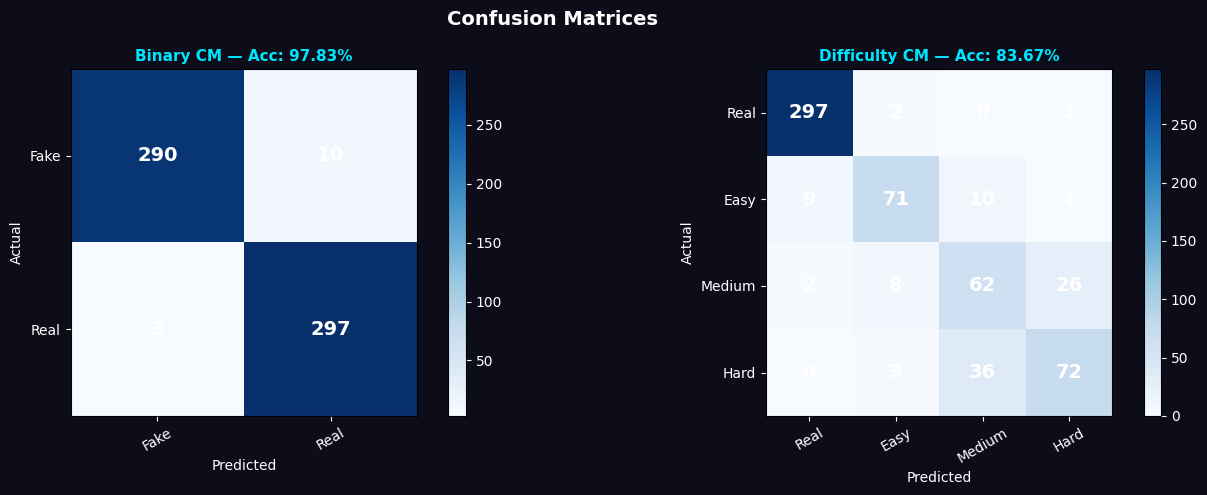

✅ Saved → confusion_matrices.png


In [10]:
@torch.no_grad()
def get_all_predictions(model, loader, device):
    model.eval()
    bin_preds, bin_probs, bin_true = [], [], []
    diff_preds, diff_true = [], []
    for imgs, b_lbl, d_lbl in loader:
        imgs = imgs.to(device)
        bin_logit, diff_logit = model(imgs)
        probs    = torch.sigmoid(bin_logit).squeeze(1).cpu().numpy()
        b_pred   = (probs >= 0.5).astype(int)
        d_pred   = diff_logit.argmax(1).cpu().numpy()
        bin_probs.extend(probs);  bin_preds.extend(b_pred);  bin_true.extend(b_lbl.numpy())
        diff_preds.extend(d_pred); diff_true.extend(d_lbl.numpy())
    return (np.array(bin_true), np.array(bin_preds), np.array(bin_probs),
            np.array(diff_true), np.array(diff_preds))

y_bin_true, y_bin_pred, y_bin_prob, y_diff_true, y_diff_pred = get_all_predictions(model, test_loader, DEVICE)

test_acc = accuracy_score(y_bin_true, y_bin_pred)
test_auc = roc_auc_score(y_bin_true, y_bin_prob)
diff_acc = accuracy_score(y_diff_true, y_diff_pred)

print("=" * 60)
print("  BINARY (Real / Fake)")
print("=" * 60)
print(f"  Accuracy : {test_acc*100:.2f}%   AUC-ROC: {test_auc:.4f}")
print()
print(classification_report(y_bin_true, y_bin_pred, target_names=["Fake", "Real"]))

print("=" * 60)
print("  DIFFICULTY (Real / Easy / Medium / Hard)")
print("=" * 60)
print(f"  Accuracy : {diff_acc*100:.2f}%")
print()
diff_labels_present = sorted(set(y_diff_true))
diff_names_present  = [DIFFICULTY_NAMES[l] for l in diff_labels_present]
print(classification_report(y_diff_true, y_diff_pred,
      labels=diff_labels_present, target_names=diff_names_present))

# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm_true, cm_pred, names, title in [
    (axes[0], y_bin_true, y_bin_pred, ["Fake", "Real"],
     f"Binary CM — Acc: {test_acc*100:.2f}%"),
    (axes[1], y_diff_true, y_diff_pred, diff_names_present,
     f"Difficulty CM — Acc: {diff_acc*100:.2f}%"),
]:
    cm = confusion_matrix(cm_true, cm_pred)
    ax.set_facecolor("#12122a")
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30); ax.set_yticklabels(names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title, color="#00e5ff", fontsize=11, fontweight="bold")
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                    color="white", fontsize=14, fontweight="bold")
    plt.colorbar(im, ax=ax)

plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1a")
plt.show()
print("✅ Saved → confusion_matrices.png")


## 📐 Biometric Metrics (EER / DET Curve)

EER: 2.00%


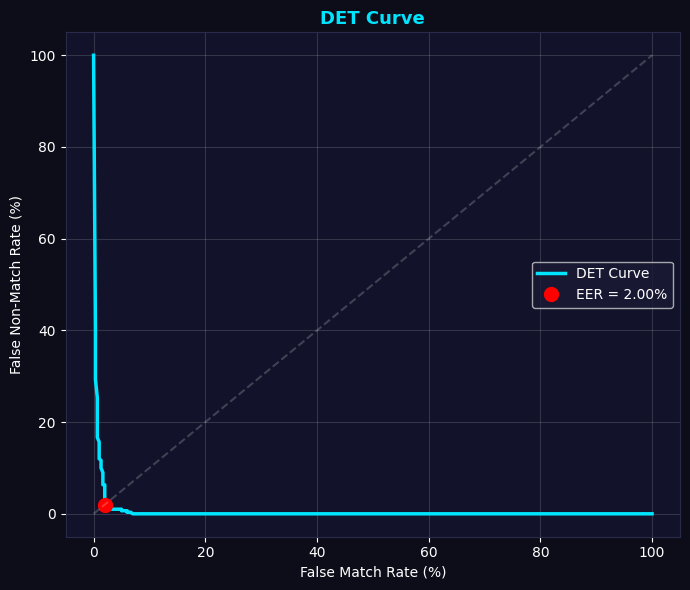

✅ Saved → det_curve.png


In [11]:
def compute_biometric_metrics(y_true, y_scores):
    thresholds = np.linspace(0, 1, 300)
    fmr_list, fnmr_list = [], []
    for t in thresholds:
        pred = (y_scores >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0,1]).ravel()
        fmr_list.append(fp / (fp + tn + 1e-9))
        fnmr_list.append(fn / (fn + tp + 1e-9))
    fmr, fnmr = np.array(fmr_list), np.array(fnmr_list)
    idx = np.argmin(np.abs(fmr - fnmr))
    eer = (fmr[idx] + fnmr[idx]) / 2
    return fmr, fnmr, thresholds, eer

fmr, fnmr, thresholds, eer = compute_biometric_metrics(y_bin_true, y_bin_prob)
print(f"EER: {eer*100:.2f}%")

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_facecolor("#12122a")
ax.plot(fmr*100, fnmr*100, color="#00e5ff", linewidth=2.5, label="DET Curve")
ax.plot([eer*100], [eer*100], "ro", markersize=10, label=f"EER = {eer*100:.2f}%")
ax.plot([0, 100], [0, 100], "w--", alpha=0.2)
ax.set_xlabel("False Match Rate (%)"); ax.set_ylabel("False Non-Match Rate (%)")
ax.set_title("DET Curve", color="#00e5ff", fontsize=13, fontweight="bold")
ax.legend(facecolor="#1a1a35", labelcolor="white")
ax.grid(True, alpha=0.15, color="white")
for s in ax.spines.values(): s.set_edgecolor("#2a2a4a")
plt.tight_layout()
plt.savefig("/kaggle/working/det_curve.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1a")
plt.show()
print("✅ Saved → det_curve.png")


## 🖼️ Sample Predictions

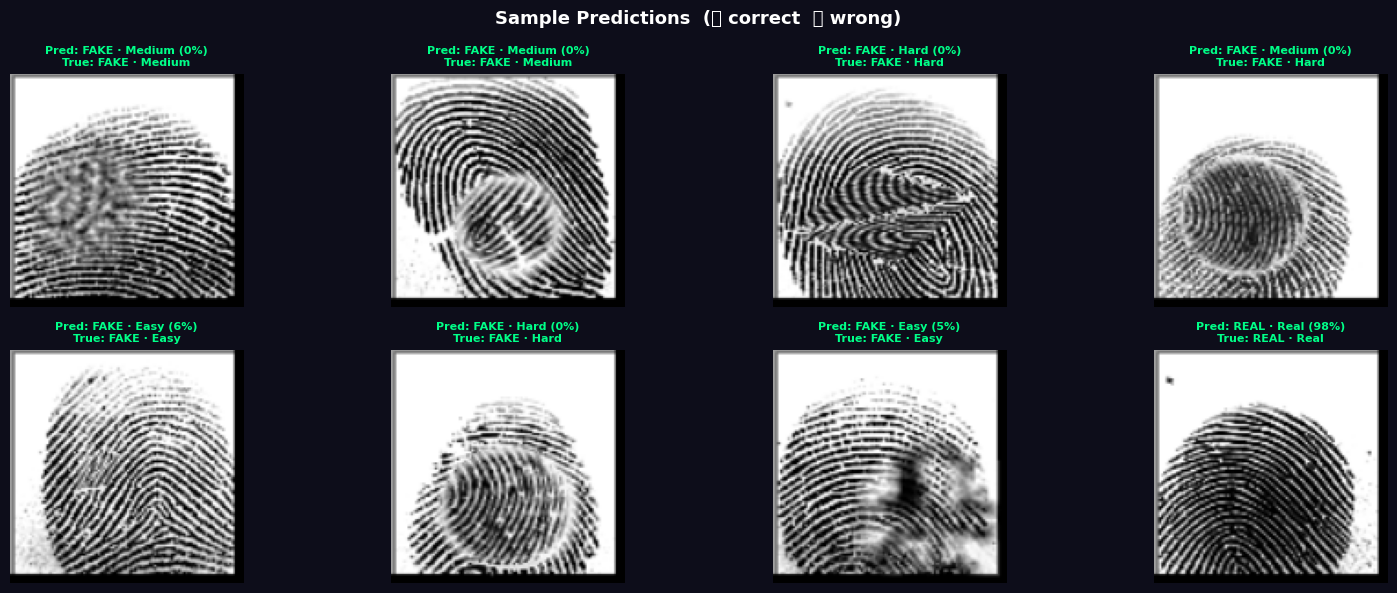

✅ Saved → sample_predictions.png


In [12]:
@torch.no_grad()
def show_predictions(model, dataset, device, n=8):
    model.eval()
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(2, n//2, figsize=(16, 6))
    fig.patch.set_facecolor("#0d0d1a")

    for ax, idx in zip(axes.flatten(), indices):
        img_t, b_lbl, d_lbl = dataset[idx]
        bin_logit, diff_logit = model(img_t.unsqueeze(0).to(device))
        prob       = torch.sigmoid(bin_logit).item()
        bin_pred   = int(prob >= 0.5)
        diff_pred  = diff_logit.argmax(1).item()

        img_np = (img_t.permute(1,2,0).numpy() * 0.5 + 0.5).clip(0,1)[:,:,0]

        correct    = bin_pred == int(b_lbl)
        color      = "#00ff88" if correct else "#ff3860"
        bin_str    = "REAL" if bin_pred == 1 else "FAKE"
        diff_str   = DIFFICULTY_NAMES[diff_pred]
        true_bin   = "REAL" if b_lbl == 1 else "FAKE"
        true_diff  = DIFFICULTY_NAMES[int(d_lbl)]

        ax.imshow(img_np, cmap="gray")
        ax.set_title(
            f"Pred: {bin_str} · {diff_str} ({prob:.0%})\nTrue: {true_bin} · {true_diff}",
            color=color, fontsize=8, fontweight="bold")
        ax.axis("off")
        for s in ax.spines.values(): s.set_edgecolor(color); s.set_linewidth(3)

    plt.suptitle("Sample Predictions  (🟢 correct  🔴 wrong)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/kaggle/working/sample_predictions.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1a")
    plt.show()

show_predictions(model, test_ds, DEVICE, n=8)
print("✅ Saved → sample_predictions.png")


## 🔬 Inference Function

Send any fingerprint image and get back **Real/Fake** + **Easy/Medium/Hard**.

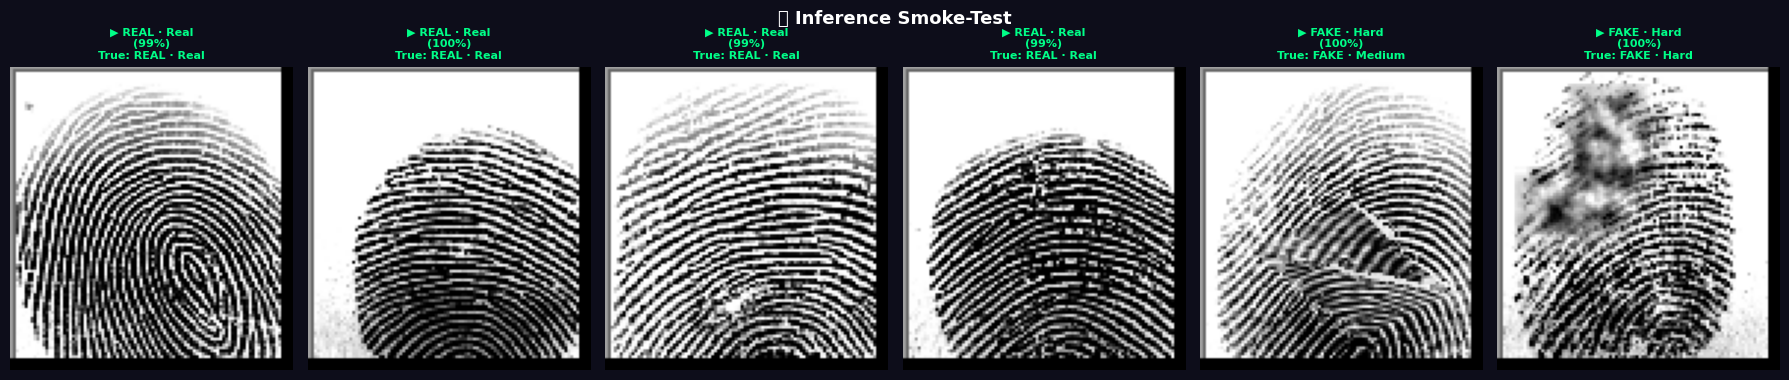


✅ predict_fingerprint() is ready!
   result = predict_fingerprint('path/to/image.bmp')
   Output keys: authenticity | difficulty | confidence | prob_real


In [13]:
@torch.no_grad()
def predict_fingerprint(image_input, model=model, device=DEVICE, threshold=0.5):
    """
    Predict a single fingerprint image.

    Parameters
    ----------
    image_input : str | Path | PIL.Image | np.ndarray

    Returns
    -------
    dict
        authenticity  : "REAL" or "FAKE"
        difficulty    : "Real" | "Easy" | "Medium" | "Hard"
        confidence    : float  (0-1, confidence in the binary prediction)
        prob_real     : float  (raw P(real) from sigmoid)

    Example
    -------
        result = predict_fingerprint("/path/to/finger.bmp")
        print(result["authenticity"], result["difficulty"], result["confidence"])
    """
    if isinstance(image_input, (str, Path)):
        img = Image.open(image_input).convert("L")
    elif isinstance(image_input, np.ndarray):
        img = Image.fromarray(image_input).convert("L")
    elif isinstance(image_input, Image.Image):
        img = image_input.convert("L")
    else:
        raise TypeError(f"Unsupported type: {type(image_input)}")

    tensor               = EVAL_TRANSFORMS(img).unsqueeze(0).to(device)
    model.eval()
    bin_logit, diff_logit = model(tensor)
    prob_real            = torch.sigmoid(bin_logit).item()
    is_real              = prob_real >= threshold
    diff_idx             = diff_logit.argmax(1).item()

    return {
        "authenticity" : "REAL" if is_real else "FAKE",
        "difficulty"   : DIFFICULTY_NAMES[diff_idx],
        "confidence"   : prob_real if is_real else 1 - prob_real,
        "prob_real"    : prob_real,
    }


def predict_batch(image_paths, model=model, device=DEVICE, threshold=0.5):
    """Run predict_fingerprint on a list of paths → DataFrame."""
    rows = []
    for p in image_paths:
        res = predict_fingerprint(p, model, device, threshold)
        rows.append({"path": str(p), **res})
    return pd.DataFrame(rows)


# ── Smoke-test on 6 random test images ───────────────────────────────────────
sample_paths = np.random.choice(p_test, 6, replace=False)

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
fig.patch.set_facecolor("#0d0d1a")

for ax, path in zip(axes, sample_paths):
    res = predict_fingerprint(path)
    true_bin, true_diff = path_to_labels[str(path)]
    true_auth = "REAL" if true_bin else "FAKE"
    true_diff_name = DIFFICULTY_NAMES[true_diff]
    correct = (res["authenticity"] == true_auth)
    color   = "#00ff88" if correct else "#ff3860"

    ax.set_facecolor("#12122a")
    ax.imshow(Image.open(path).convert("L"), cmap="gray")
    ax.set_title(
        f"▶ {res['authenticity']} · {res['difficulty']}\n"
        f"({res['confidence']:.0%})\n"
        f"True: {true_auth} · {true_diff_name}",
        color=color, fontsize=8, fontweight="bold")
    ax.axis("off")
    for s in ax.spines.values(): s.set_edgecolor(color); s.set_linewidth(3)

plt.suptitle("🔬 Inference Smoke-Test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/inference_test.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1a")
plt.show()

print("\n✅ predict_fingerprint() is ready!")
print("   result = predict_fingerprint(\'path/to/image.bmp\')")
print("   Output keys: authenticity | difficulty | confidence | prob_real")


## 💾 Save & Final Summary

In [14]:
torch.save(model.state_dict(), "/kaggle/working/fingerprint_cnn.pth")
print("✅ Model saved → fingerprint_cnn.pth")

summary = {
    "model"          : "MobileNetV2 DualHead",
    "binary_accuracy": round(float(test_acc)  * 100, 2),
    "diff_accuracy"  : round(float(diff_acc)  * 100, 2),
    "auc_roc"        : round(float(test_auc),          4),
    "eer"            : round(float(eer)        * 100, 2),
    "best_val_acc"   : round(best_val_acc      * 100, 2),
    "epochs_trained" : len(history["train_acc"]),
    "img_size"       : CONFIG["img_size"],
    "pretrained"     : CONFIG["use_pretrained"],
}
with open("/kaggle/working/metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 50)
print("  FINAL SUMMARY")
print("=" * 50)
for k, v in summary.items():
    print(f"  {k:<20}: {v}")


✅ Model saved → fingerprint_cnn.pth

  FINAL SUMMARY
  model               : MobileNetV2 DualHead
  binary_accuracy     : 97.83
  diff_accuracy       : 83.67
  auc_roc             : 0.9954
  eer                 : 2.0
  best_val_acc        : 96.33
  epochs_trained      : 30
  img_size            : 128
  pretrained          : True


## 🖥️ Interactive GUI (Gradio)

Drag and drop a fingerprint image → instantly get **Real/Fake** + difficulty level.

In [15]:
# Install Gradio if not already available
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "gradio", "-q"])

import gradio as gr
import numpy as np
from PIL import Image

# ── Color map for difficulty ───────────────────────────────────────────────────
DIFF_COLORS = {
    "Real"   : "#00c853",
    "Easy"   : "#ffab00",
    "Medium" : "#ff6d00",
    "Hard"   : "#d50000",
}

def run_inference(pil_image):
    """Gradio handler: receives PIL Image, returns formatted result."""
    if pil_image is None:
        return (
            "No image provided",
            "—",
            0.0,
            "<p style='color:#888'>Upload a fingerprint image to get a prediction.</p>"
        )

    result = predict_fingerprint(pil_image)

    auth       = result["authenticity"]      # "REAL" or "FAKE"
    difficulty = result["difficulty"]        # "Real" / "Easy" / "Medium" / "Hard"
    confidence = result["confidence"]        # float 0-1
    prob_real  = result["prob_real"]

    diff_color = DIFF_COLORS.get(difficulty, "#888")
    auth_color = "#00c853" if auth == "REAL" else "#d50000"

    html_out = f"""
    <div style="font-family: monospace; padding: 16px; border-radius: 12px;
                background: #0d0d1a; color: white; line-height: 2;">
      <div style="font-size: 28px; font-weight: bold; color: {auth_color};">
        {'✅' if auth == 'REAL' else '❌'} {auth}
      </div>
      <div style="font-size: 18px; margin-top: 8px;">
        Difficulty:
        <span style="color: {diff_color}; font-weight: bold;">{difficulty}</span>
      </div>
      <div style="margin-top: 8px; font-size: 14px; color: #aaa;">
        Confidence: <b style="color:white;">{confidence*100:.1f}%</b>
        &nbsp;|&nbsp; P(Real): <b style="color:white;">{prob_real*100:.1f}%</b>
      </div>
      <div style="margin-top: 12px; background: #1a1a2e; border-radius: 8px;
                  height: 10px; overflow: hidden;">
        <div style="height: 100%; width: {prob_real*100:.1f}%;
                    background: linear-gradient(90deg, #ff4444, #00c853);
                    border-radius: 8px;"></div>
      </div>
      <div style="display: flex; justify-content: space-between;
                  font-size: 11px; color: #666; margin-top: 2px;">
        <span>FAKE</span><span>REAL</span>
      </div>
    </div>
    """
    return auth, difficulty, round(confidence * 100, 1), html_out


# ── Gradio Interface ──────────────────────────────────────────────────────────
with gr.Blocks(
    title="Fingerprint Detector",
    theme=gr.themes.Base(),
    css="""
    body { background: #0d0d1a !important; }
    .gradio-container { background: #0d0d1a !important; color: white !important; }
    h1 { color: #00e5ff !important; text-align: center; font-family: monospace; }
    .label-wrap label { color: #aaa !important; }
    """
) as demo:

    gr.Markdown("# 🔍 Fingerprint Authenticity Detector")
    gr.Markdown(
        "Upload a fingerprint scan. The model will classify it as "
        "**Real or Fake** and — if fake — estimate the **difficulty level** "
        "(Easy / Medium / Hard).",
    )

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(
                type="pil",
                label="Upload Fingerprint",
                image_mode="L",
            )
            predict_btn = gr.Button("🔎 Analyse", variant="primary")

        with gr.Column(scale=1):
            result_html  = gr.HTML(label="Result")
            with gr.Row():
                out_auth  = gr.Textbox(label="Authenticity", interactive=False)
                out_diff  = gr.Textbox(label="Difficulty",   interactive=False)
                out_conf  = gr.Number( label="Confidence (%)", interactive=False)

    # Example images from the test set (if available)
    sample_paths_for_gui = p_test[:6]
    if sample_paths_for_gui:
        gr.Examples(
            examples=[[str(p)] for p in sample_paths_for_gui],
            inputs=image_input,
            label="Example images from test set",
        )

    predict_btn.click(
        fn=run_inference,
        inputs=[image_input],
        outputs=[out_auth, out_diff, out_conf, result_html],
    )
    image_input.change(          # also run on upload without pressing the button
        fn=run_inference,
        inputs=[image_input],
        outputs=[out_auth, out_diff, out_conf, result_html],
    )

demo.launch(share=True, debug=False)
# Public URL will be printed above — valid for 72 hours on Kaggle


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://4e104693015e1de740.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
